In [1]:
%matplotlib inline

# air passenger data example

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# The actual data is available as a pandas DataFrame via the 'data' attribute
df_airp = pd.read_csv("us-airlines-monthly-aircraft-miles-flown.csv", parse_dates=[0])

# Print the first few rows to verify
print(df_airp.head())

       Month  MilesMM
0 1963-01-01     6827
1 1963-02-01     6178
2 1963-03-01     7084
3 1963-04-01     8162
4 1963-05-01     8462


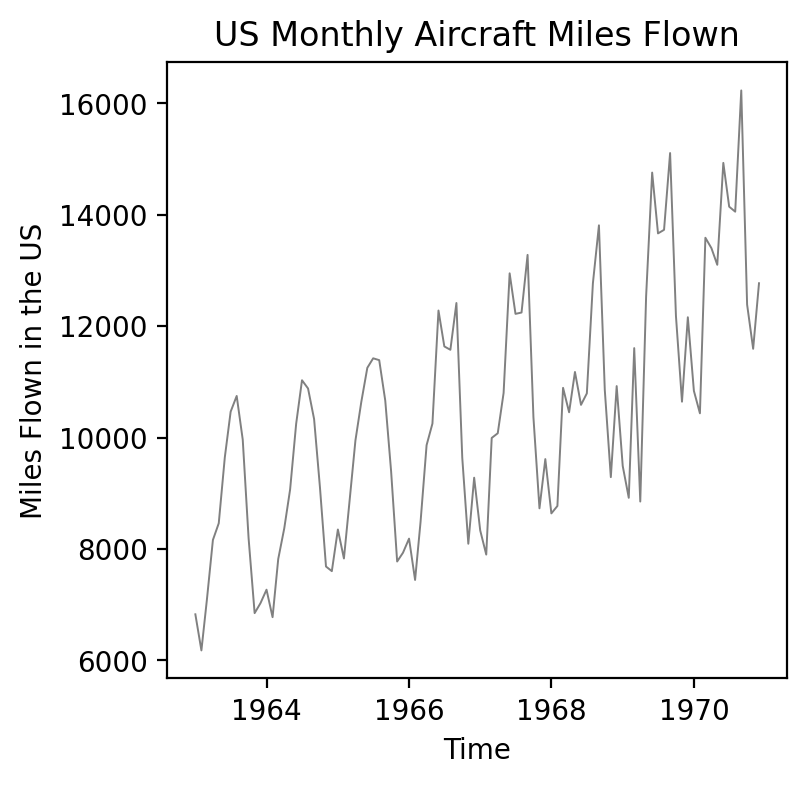

In [4]:
plt.figure(figsize=[4,4],dpi=200)
plt.plot(df_airp['Month'], df_airp['MilesMM'], ls='-', c='gray', lw=0.7)
plt.xlabel('Time')
plt.ylabel('Miles Flown in the US')
plt.title('US Monthly Aircraft Miles Flown')
plt.xticks(df_airp['Month'][12::24],np.arange(1964,1971,2))
plt.show()

In [5]:
df_airp['Month'][0::12]

0    1963-01-01
12   1964-01-01
24   1965-01-01
36   1966-01-01
48   1967-01-01
60   1968-01-01
72   1969-01-01
84   1970-01-01
Name: Month, dtype: datetime64[us]

In [6]:
import numpy as np

def rle_numpy(a):
    """
    Run-length encode a 1D numpy array.
    Returns (lengths, values) like R's rle().
    """
    a = np.asarray(a)
    if a.size == 0:
        return np.array([], dtype=int), np.array([], dtype=a.dtype)

    # Identify run starts: True at index 0 and whenever value changes
    run_starts = np.r_[True, a[1:] != a[:-1]]
    # Indices where runs start
    idx = np.flatnonzero(run_starts)
    # Run lengths are the gaps between start indices (plus tail to end)
    lengths = np.diff(np.r_[idx, a.size])
    values = a[run_starts]
    return lengths, values

In [7]:
import numpy as np
x = np.array(np.random.default_rng(43).random(20), dtype=float)
diff = np.diff(x,n=1)
sign_diff = np.sign(diff)
lengths, values = rle_numpy(sign_diff)  

print("sign(diff(x)) =", sign_diff)
print("lengths =", lengths) 
print("values  =", values)  
print(f"We have a total of {len(lengths)} reversals")

sign(diff(x)) = [-1. -1.  1. -1. -1.  1. -1.  1.  1.  1. -1. -1. -1.  1. -1.  1.  1. -1.
 -1.]
lengths = [2 1 2 1 1 3 3 1 1 2 2]
values  = [-1.  1. -1.  1. -1.  1. -1.  1. -1.  1. -1.]
We have a total of 11 reversals


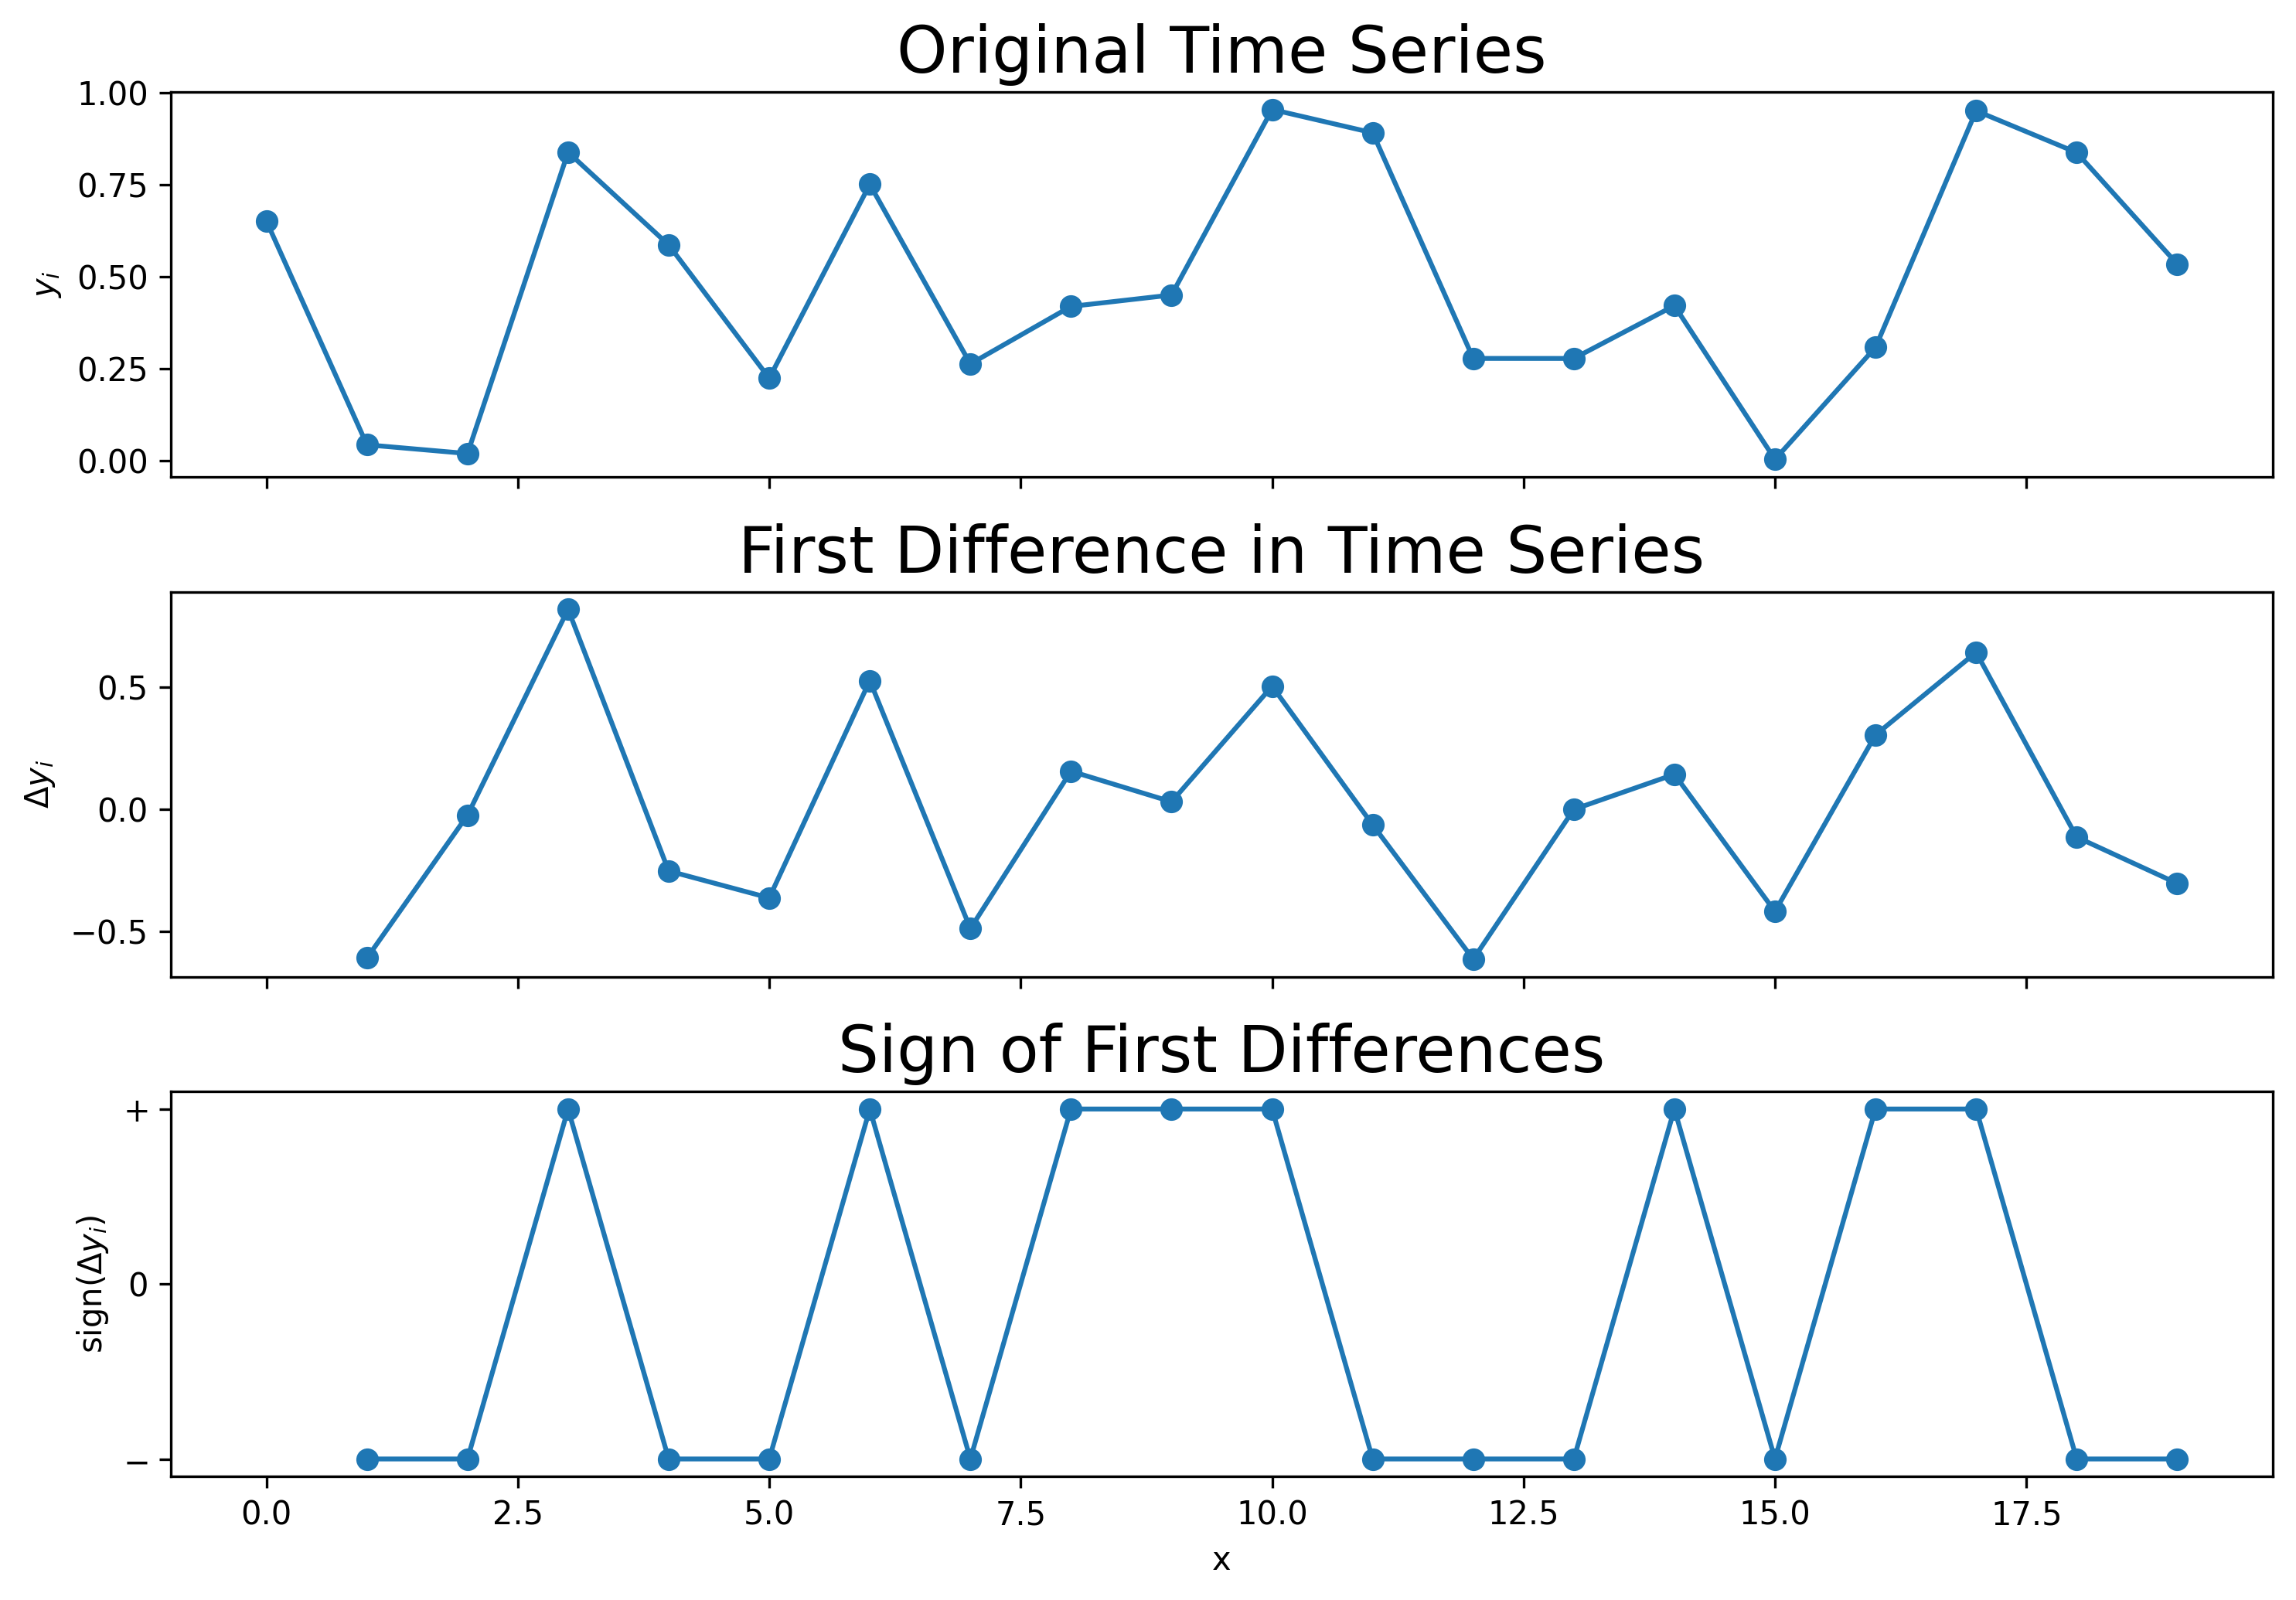

In [8]:
fig,ax = plt.subplots(3,1,sharex=True,figsize=[10,7],dpi=300,)
ax[0].plot(np.arange( len(x)), x, marker='o')
ax[0].set_ylabel(r"$y_i$")
ax[0].set_title("Original Time Series", fontsize=20)
ax[1].plot(np.arange(1, len(x)), diff, marker='o')
ax[1].set_ylabel(r"$\Delta y_i$")
ax[1].set_title("First Difference in Time Series", fontsize=20)
ax[2].plot(np.arange(1, len(x)), sign_diff, marker='o')
ax[2].set_xlabel("x")
ax[2].set_yticks([-1,0,1])
ax[2].set_yticklabels([r"$-$", 0, r"$+$"])
ax[2].set_ylabel(r"$\operatorname{sign}(\Delta y_i)$")
ax[2].set_title("Sign of First Differences", fontsize=20)

plt.tight_layout()

In [9]:

from turning_point import turning_point_test

data = [1, 3, 2, 4, 3, 5, 1]
result = turning_point_test(data)
print(result)


TurningPointTestResult(n=7, n_effective=7, T=5, mu=3.3333333333333335, var=0.9222222222222223, z=1.2148677353760906, p_value=0.22441654130073818)


In [10]:
# make sure that the input data into turning_point_test is a list, not a numpy array
turning_point_test(x.tolist())

TurningPointTestResult(n=20, n_effective=20, T=10, mu=12.0, var=3.2333333333333334, z=-0.8341919974800728, p_value=0.404172799917852)

# Apply Phase Length Distribution test

In [11]:
from phase_length_test import phase_length_distribution_test,monotonic_phase_lengths
monotonic_phase_lengths(x)

[3, 2, 3, 2, 2, 4, 4, 2, 2, 3, 3]

In [12]:
# apply the phase length distribution test to the data
res = phase_length_distribution_test(x, B=2000, seed=1)
print(res.p_perm, res.statistic)

0.17841079460269865 2.2272727272727266


In [13]:
res

PhaseLengthTestResult(n=20, n_effective=20, n_phases=11, bins=['2', '≥3'], observed_counts=array([5, 6]), expected_counts=array([7.33333333, 3.66666667]), statistic=2.2272727272727266, p_perm=0.17841079460269865, B=2000, q_null=0.6666666666666666, seed=1)

# random walk

In [14]:
import numpy as np

def random_walk(n_steps=1000, seed=0):
    np.random.seed(seed)
    steps = np.random.choice([-1, 1], size=n_steps)
    return np.cumsum(steps)

# Example usage:
rw = random_walk(100)

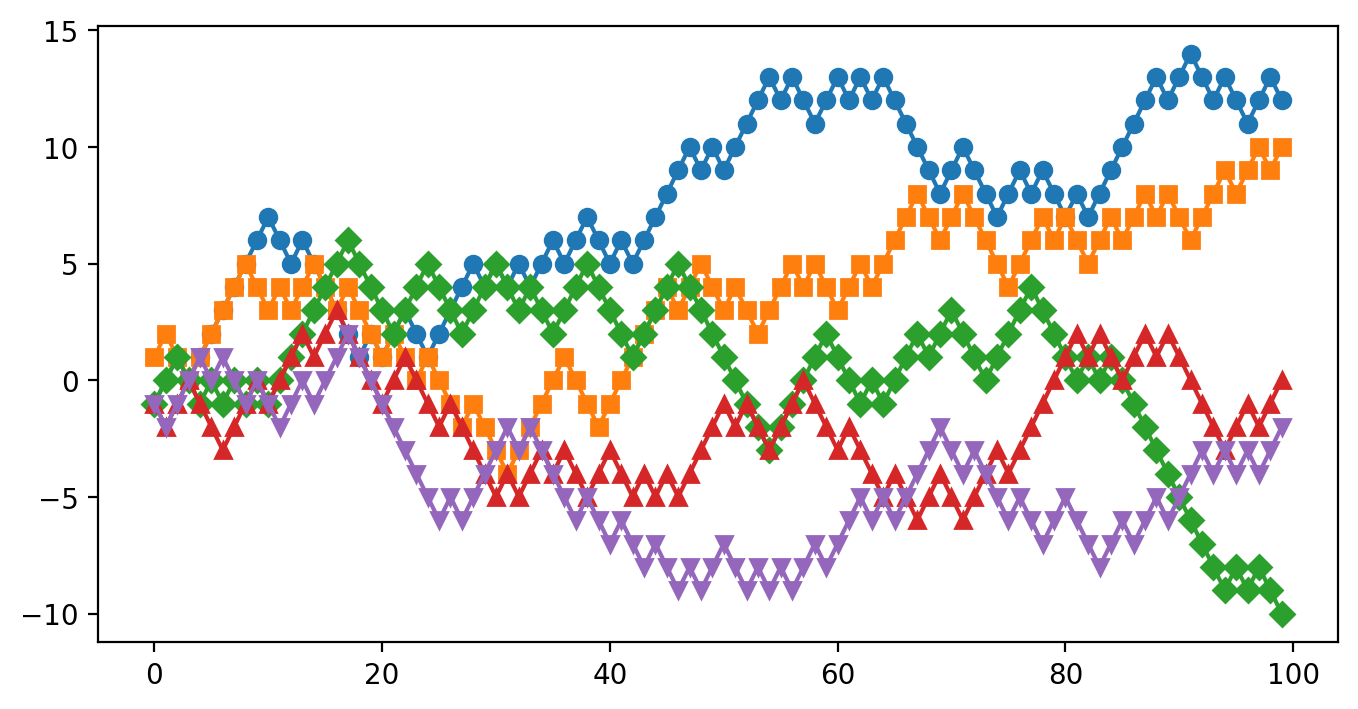

In [15]:
markers = ['o', 's', 'D', '^', 'v']
plt.figure(figsize=[8,4],dpi=200)
for seed in range(5):
    rw = random_walk(100, seed=seed)
    plt.plot(rw, marker=markers[seed])

# 2.1. Count Increase Test

In [16]:
from count_increase_test import count_increases_test

In [17]:
# Example 1: no trend (i.i.d. noise)
import numpy as np
rng = np.random.default_rng(0)
x = rng.normal(size=60)
res = count_increases_test(x, alternative="two-sided")
print(res)

# Example 2: increasing trend
t = np.arange(60)
x_trend = 1 * t + rng.normal(scale=0.5, size=60)
res_inc = count_increases_test(x_trend, alternative="increasing")
print(res_inc)

CountIncreasesResult(n=60, n_trials=59, n_increases=32, n_decreases=27, n_ties=0, alternative='two-sided', p_value=0.6029232012571436)
CountIncreasesResult(n=60, n_trials=59, n_increases=52, n_decreases=7, n_ties=0, alternative='increasing', p_value=6.794958901101688e-10)


In [18]:
# test the random walk increasing trend
for seed in range(5):
    rw = random_walk(100, seed=seed)
    res = count_increases_test(rw, alternative="two-sided")
    print(res)

CountIncreasesResult(n=100, n_trials=99, n_increases=56, n_decreases=43, n_ties=0, alternative='two-sided', p_value=0.22762615711004633)
CountIncreasesResult(n=100, n_trials=99, n_increases=54, n_decreases=45, n_ties=0, alternative='two-sided', p_value=0.4215233436157732)
CountIncreasesResult(n=100, n_trials=99, n_increases=45, n_decreases=54, n_ties=0, alternative='two-sided', p_value=0.4215233436157732)
CountIncreasesResult(n=100, n_trials=99, n_increases=50, n_decreases=49, n_ties=0, alternative='two-sided', p_value=1.0)
CountIncreasesResult(n=100, n_trials=99, n_increases=49, n_decreases=50, n_ties=0, alternative='two-sided', p_value=1.0)


# 2.2. Kendall's Tau test

In [19]:
from scipy.stats import kendalltau

In [20]:
# you may view x as time dimension (monotically increasing), and y as the corresponding variable.
t = np.arange(60)
rng = np.random.default_rng(0)
x_trend = 1 * t + rng.normal(scale=0.5, size=60)

tau, p_value = kendalltau(t, x_trend)

print("Kendall tau:", tau)
print("p-value:", p_value)


Kendall tau: 0.9966101694915255
p-value: 2.2985232984630205e-29


# 3.1. Friedman’s Test 

In [21]:
from scipy.stats import friedmanchisquare

# Example: 3 treatments measured on the same subjects
treatment1 = [10, 12, 9, 11, 13]
treatment2 = [9, 11, 10, 10, 12]
treatment3 = [12, 14, 11, 13, 15]

stat, p = friedmanchisquare(treatment1, treatment2, treatment3)

print("Chi-square statistic:", stat)
print("p-value:", p)

Chi-square statistic: 8.400000000000006
p-value: 0.01499557682047766


## example: perform Friedman's test on the aircraft miles flown dataset

In [22]:
# 1) Load your file
df_airp = pd.read_csv("us-airlines-monthly-aircraft-miles-flown.csv", parse_dates=[0])


# 2) Parse dates and build Year/Month fields
df_airp["Month"] = pd.to_datetime(df_airp["Month"])
df_airp["Year"] = df_airp["Month"].dt.year
df_airp["Mon"] = df_airp["Month"].dt.month

# 3) Pivot to Year x Month matrix (blocks x treatments)
pv = df_airp.pivot(index="Year", columns="Mon", values="MilesMM")

pv

Mon,1,2,3,4,5,6,7,8,9,10,11,12
Year,,,,,,,,,,,,
1963,6827,6178,7084,8162,8462,9644,10466,10748,9963,8194,6848,7027
1964,7269,6775,7819,8371,9069,10248,11030,10882,10333,9109,7685,7602
1965,8350,7829,8829,9948,10638,11253,11424,11391,10665,9396,7775,7933
1966,8186,7444,8484,9864,10252,12282,11637,11577,12417,9637,8094,9280
1967,8334,7899,9994,10078,10801,12950,12222,12246,13281,10366,8730,9614
1968,8639,8772,10894,10455,11179,10588,10794,12770,13812,10857,9290,10925
1969,9491,8919,11607,8852,12537,14759,13667,13731,15110,12185,10645,12161
1970,10840,10436,13589,13402,13103,14933,14147,14057,16234,12389,11595,12772


In [23]:
# Keep only years with all 12 months present
pv_complete = pv.dropna()
pv_complete

Mon,1,2,3,4,5,6,7,8,9,10,11,12
Year,,,,,,,,,,,,
1963,6827,6178,7084,8162,8462,9644,10466,10748,9963,8194,6848,7027
1964,7269,6775,7819,8371,9069,10248,11030,10882,10333,9109,7685,7602
1965,8350,7829,8829,9948,10638,11253,11424,11391,10665,9396,7775,7933
1966,8186,7444,8484,9864,10252,12282,11637,11577,12417,9637,8094,9280
1967,8334,7899,9994,10078,10801,12950,12222,12246,13281,10366,8730,9614
1968,8639,8772,10894,10455,11179,10588,10794,12770,13812,10857,9290,10925
1969,9491,8919,11607,8852,12537,14759,13667,13731,15110,12185,10645,12161
1970,10840,10436,13589,13402,13103,14933,14147,14057,16234,12389,11595,12772


In [24]:
# 4) Friedman test across the 12 month columns (blocks = years)
samples = [pv_complete[m].values for m in sorted(pv_complete.columns)]
stat, p = friedmanchisquare(*samples)

print(f"Years used (blocks): {pv_complete.index.min()}–{pv_complete.index.max()}  (n={pv_complete.shape[0]})")
print(f"Treatments (months): {len(samples)}")
print(f"Friedman chi-square: {stat:.3f},  p-value: {p:.3e}")

Years used (blocks): 1963–1970  (n=8)
Treatments (months): 12
Friedman chi-square: 74.019,  p-value: 2.090e-11


In [25]:
# 5) Which months are high/low?  Rank within each year and average
ranks = pv_complete.rank(axis=1, method="average")
mean_ranks = ranks.mean(axis=0).sort_values(ascending=False)

# Helper to map month numbers to names
import calendar
mean_ranks_named = {calendar.month_name[m]: r for m, r in mean_ranks.items()}

print("\nAverage within-year ranks by month (higher = larger MilesMM):")
for m, r in mean_ranks_named.items():
    print(f"{m:>9}: {r:5.3f}")


Average within-year ranks by month (higher = larger MilesMM):
September: 11.125
   August: 10.375
     July: 9.875
     June: 9.625
      May: 7.875
  October: 6.500
    March: 5.625
    April: 5.500
 December: 4.875
 November: 2.875
  January: 2.375
 February: 1.375
